<a href="https://colab.research.google.com/github/IT24100378/ToxicCommentNLPfinal/blob/Tokenization/Tokenization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Load dataset
import csv
df = pd.read_csv("PunctCleanedDataset.csv", on_bad_lines='skip', engine='python')



# Show dataset info and first 5 rows
print("\nDataset Info:")
print(df.info())
print("\nFirst 5 Rows:")
print(df.head())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   cleaned_comment  16000 non-null  object
 1   toxic            16000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 250.1+ KB
None

First 5 Rows:
                                     cleaned_comment  toxic
0  \r\n\r\n lighten up francis \r\n\r\non same te...      0
1  lisa williams is a total fraud \r\nno offense ...      1
2  i am david in dc not davidindc on at least one...      1
3  fuck you  \r\n\r\n \r\nfuck you keep blocking ...      1
4  both entries are on the same subject they shou...      0



After Preprocessing Dataset Summary:
         char_count    word_count
count  16000.000000  16000.000000
mean     340.258125     59.791875
std      596.559379    104.038270
min        5.000000      1.000000
25%       72.000000     13.000000
50%      159.000000     29.000000
75%      347.000000     62.000000
max     5000.000000   1403.000000


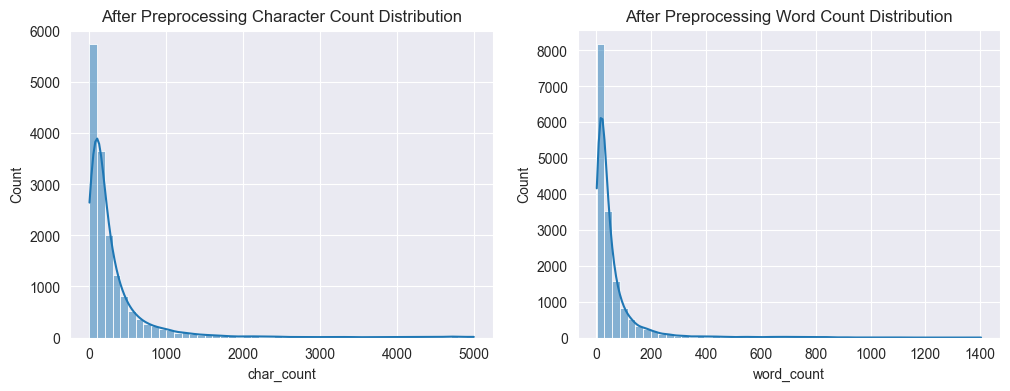

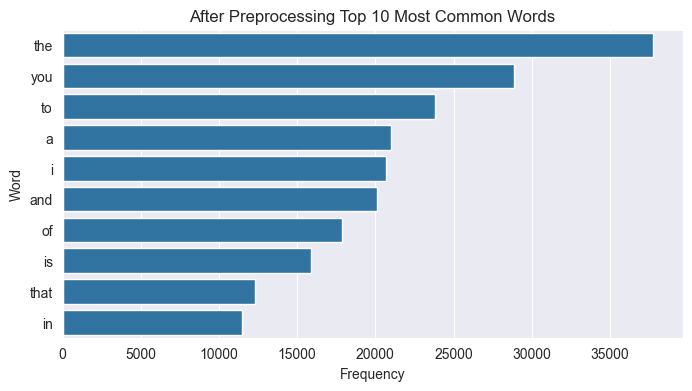

In [2]:
# ----- EDA Function for Text -----
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import pandas as pd

def text_eda(data, column_name="cleaned_comment", title_prefix=""):
    # Text length features
    data["char_count"] = data[column_name].apply(lambda x: len(str(x)))
    data["word_count"] = data[column_name].apply(lambda x: len(str(x).split()))

    # Summary statistics
    print(f"\n{title_prefix} Dataset Summary:")
    print(data[[column_name, "char_count", "word_count"]].describe())

    # Distribution plots
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(data["char_count"], bins=50, ax=axes[0], kde=True)
    axes[0].set_title(f"{title_prefix} Character Count Distribution")
    sns.histplot(data["word_count"], bins=50, ax=axes[1], kde=True)
    axes[1].set_title(f"{title_prefix} Word Count Distribution")
    plt.show()

    # Most common words
    all_words = " ".join(data[column_name].astype(str)).split()
    common_words = Counter(all_words).most_common(10)
    common_df = pd.DataFrame(common_words, columns=["Word", "Frequency"])

    plt.figure(figsize=(8,4))
    sns.barplot(x="Frequency", y="Word", data=common_df)
    plt.title(f"{title_prefix} Top 10 Most Common Words")
    plt.show()

# ----- Run EDA on Cleaned Text -----
text_eda(df.copy(), column_name="cleaned_comment", title_prefix="After Preprocessing")


In [4]:
# ----- Preprocessing (Tokenization) -----
df_tokenized = df.copy()
df_tokenized["tokens"] = df_tokenized["cleaned_comment"].apply(lambda x: str(x).split())
print(" Data has been preprocessed: text has been tokenized into word lists.")

# Show sample
df_tokenized[[ 'cleaned_comment', 'tokens', 'toxic']].head()


 Data has been preprocessed: text has been tokenized into word lists.


,cleaned_comment,tokens,toxic
0,\r\n\r\n lighten up francis \r\n\r\non same te...,"[lighten, up, francis, on, same, team, in, gen...",0
1,lisa williams is a total fraud \r\nno offense ...,"[lisa, williams, is, a, total, fraud, no, offe...",1
2,i am david in dc not davidindc on at least one...,"[i, am, david, in, dc, not, davidindc, on, at,...",1
3,fuck you \r\n\r\n \r\nfuck you keep blocking ...,"[fuck, you, fuck, you, keep, blocking, me, ill...",1
4,both entries are on the same subject they shou...,"[both, entries, are, on, the, same, subject, t...",0



After Tokenization Dataset Summary (Tokenized):
         char_count    word_count
count  16000.000000  16000.000000
mean     275.042000     59.791875
std      486.811483    104.038270
min        5.000000      1.000000
25%       57.000000     13.000000
50%      127.000000     29.000000
75%      280.000000     62.000000
max     4958.000000   1403.000000


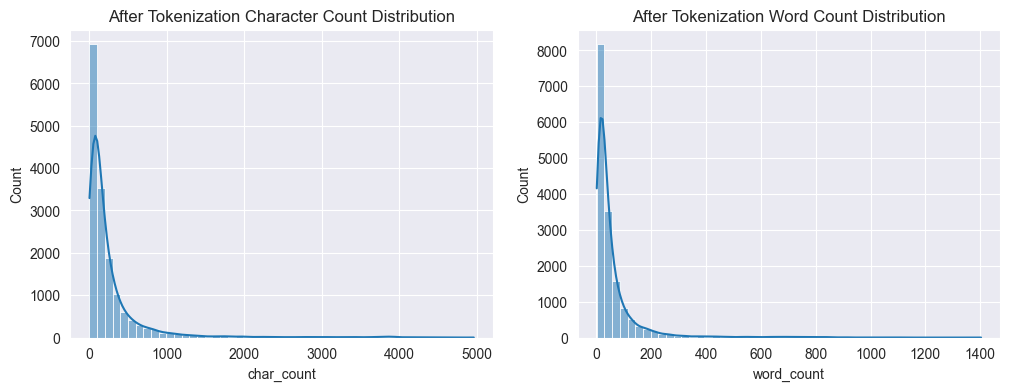

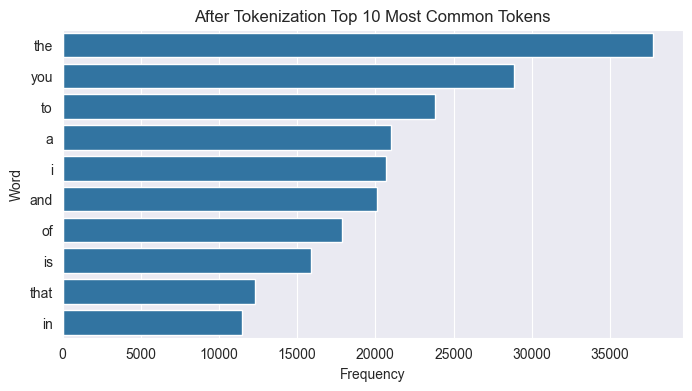

In [5]:
# ----- EDA Function for Tokenized Data -----
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import pandas as pd

def token_eda(data, column_name="tokens", title_prefix=""):
    # Word count per comment
    data["word_count"] = data[column_name].apply(len)
    data["char_count"] = data[column_name].apply(lambda x: sum(len(w) for w in x))

    # Summary statistics
    print(f"\n{title_prefix} Dataset Summary (Tokenized):")
    print(data[["char_count", "word_count"]].describe())

    # Distribution plots
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(data["char_count"], bins=50, ax=axes[0], kde=True)
    axes[0].set_title(f"{title_prefix} Character Count Distribution")
    sns.histplot(data["word_count"], bins=50, ax=axes[1], kde=True)
    axes[1].set_title(f"{title_prefix} Word Count Distribution")
    plt.show()

    # Most common tokens
    all_words = [w for tokens in data[column_name] for w in tokens]
    common_words = Counter(all_words).most_common(10)
    common_df = pd.DataFrame(common_words, columns=["Word", "Frequency"])

    plt.figure(figsize=(8,4))
    sns.barplot(x="Frequency", y="Word", data=common_df)
    plt.title(f"{title_prefix} Top 10 Most Common Tokens")
    plt.show()

# ----- EDA After Tokenization -----
token_eda(df_tokenized.copy(), column_name="tokens", title_prefix="After Tokenization")


In [6]:
# ----- Save Tokenized Dataset -----
# Keep only the required columns
final_tokenized = df_tokenized[[ 'tokens', 'toxic']]

# Save to CSV
final_tokenized.to_csv("train_tokenized.csv", index=False)
print(" Tokenized dataset saved as train_tokenized.csv")


 Tokenized dataset saved as train_tokenized.csv


/tmp/ipython-input-1326968189.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Freq", y="Word", data=words_df, ax=axes[0], palette="Blues_d")
/tmp/ipython-input-1326968189.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Freq", y="Token", data=tokens_df, ax=axes[1], palette="Greens_d")


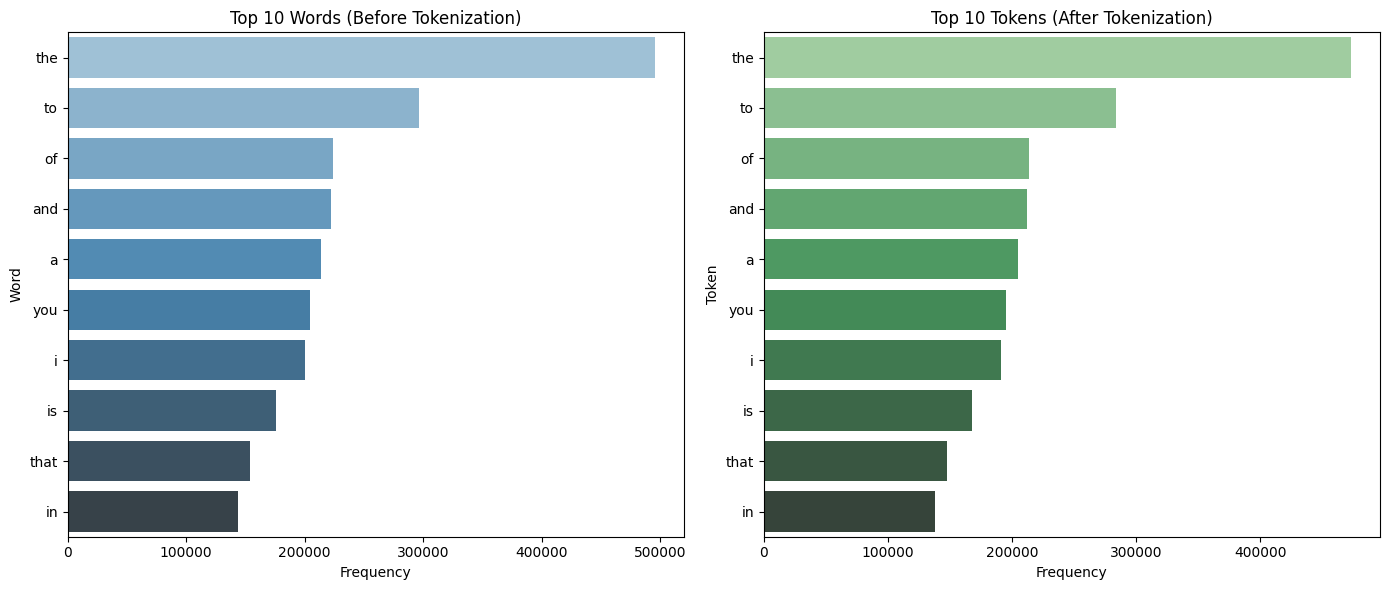

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import pandas as pd

# ----- Prepare Top Words and Tokens -----
top_n = 10

# Load preprocessed dataset (only has id, cleaned_comment, toxic)
df = pd.read_csv("/content/train_preprocessed_cleaned.csv", on_bad_lines='skip', engine='python')

# Top words BEFORE tokenization (from cleaned_comment)
words_before = " ".join(df["cleaned_comment"].astype(str)).split()
common_words = Counter(words_before).most_common(top_n)
words_df = pd.DataFrame(common_words, columns=["Word", "Freq"])

# Top tokens AFTER tokenization
tokens_after = [token for tokens in df_tokenized["tokens"] for token in tokens]
common_tokens = Counter(tokens_after).most_common(top_n)
tokens_df = pd.DataFrame(common_tokens, columns=["Token", "Freq"])

# ----- Plot Side by Side -----
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Before tokenization
sns.barplot(x="Freq", y="Word", data=words_df, ax=axes[0], palette="Blues_d")
axes[0].set_title("Top 10 Words (Before Tokenization)")
axes[0].set_xlabel("Frequency")
axes[0].set_ylabel("Word")

# After tokenization
sns.barplot(x="Freq", y="Token", data=tokens_df, ax=axes[1], palette="Greens_d")
axes[1].set_title("Top 10 Tokens (After Tokenization)")
axes[1].set_xlabel("Frequency")
axes[1].set_ylabel("Token")

plt.tight_layout()
plt.show()
